In [1]:
import pandas as pd
df = pd.read_csv('../raw_data/cleaned_data.csv', parse_dates=['founded_at', 'first_funding_at', 'last_funding_at'])
print(f"Loaded: {df.shape}")

Loaded: (45708, 33)


In [2]:
# Drop rows where status is "unknown" (were NaN, can't label them)
df = df[df['status'] != 'unknown']

# Target: success (1) = acquired or operating, failure (0) = closed
df['target'] = (df['status'].isin(['acquired', 'operating'])).astype(int)

print(f"Rows: {df.shape[0]}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].mean():.1%} success / {1-df['target'].mean():.1%} closed")

Rows: 44535

Target distribution:
target
1    42034
0     2501
Name: count, dtype: int64

Class balance: 94.4% success / 5.6% closed


In [ ]:
# FEATURE SETUP

# All numeric features
X_num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['target']).columns.tolist()

# Categorical — only manageable cardinality
cat_features = ['country_code', 'state_code']

# Dropped permalink and status from consideration (ID and target)
# Dropped category_list, market, region (too high cardinality for baseline)

X = df[X_num_cols + cat_features].copy()
y = df['target'].copy()

print(f"Total features: {len(X.columns)} ({len(X_num_cols)} numeric + {len(cat_features)} categorical)")

Total features: 25 (23 numeric + 2 categorical)


In [4]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Class balance: {y_train.mean():.1%} success / {1-y_train.mean():.1%} closed")

Train: 35628 rows | Test: 8907 rows
Class balance: 94.4% success / 5.6% closed


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), X_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
])

In [ ]:
# MODEL COMPARISON

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, RocCurveDisplay

models = {
    'LogReg (balanced)': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ]),
    'Decision Tree (balanced)': Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]),
    'Random Forest (balanced)': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ]),
    'KNN (k=5)': Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, pipe in models.items():
    print(f"\nTraining: {name}...")
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    f1_closed = f1_score(y_test, y_pred, pos_label=0)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')

    results.append({
        'Model': name,
        'AUC (test)': round(auc, 4),
        'F1 closed': round(f1_closed, 4),
        'CV AUC (mean)': round(cv_auc.mean(), 4),
        'CV AUC (std)': round(cv_auc.std(), 4),
    })
    print(f"  AUC: {auc:.4f} | F1 closed: {f1_closed:.4f} | CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")


Training: LogReg (balanced)...
  AUC: 0.6054 | F1 closed: 0.1266 | CV AUC: 0.6034 ± 0.0057

Training: Decision Tree (balanced)...
  AUC: 0.5431 | F1 closed: 0.1313 | CV AUC: 0.5482 ± 0.0101

Training: Random Forest (balanced)...
  AUC: 0.5685 | F1 closed: 0.1383 | CV AUC: 0.5780 ± 0.0205

Training: KNN (k=5)...
  AUC: 0.5264 | F1 closed: 0.0113 | CV AUC: 0.5432 ± 0.0126

Training: Gradient Boosting...
  AUC: 0.6527 | F1 closed: 0.0000 | CV AUC: 0.6382 ± 0.0088


In [ ]:
# RESULTS

results_df = pd.DataFrame(results).sort_values('AUC (test)', ascending=False)
print("\n" + "=" * 80)
print("BASELINE MODEL COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))


BASELINE MODEL COMPARISON
                   Model  AUC (test)  F1 closed  CV AUC (mean)  CV AUC (std)
       Gradient Boosting      0.6527     0.0000         0.6382        0.0088
       LogReg (balanced)      0.6054     0.1266         0.6034        0.0057
Random Forest (balanced)      0.5685     0.1383         0.5780        0.0205
Decision Tree (balanced)      0.5431     0.1313         0.5482        0.0101
               KNN (k=5)      0.5264     0.0113         0.5432        0.0126


In [ ]:
# BEST MODEL — DETAILED REPORT

best_name = results_df.iloc[0]['Model']
best_pipe = models[best_name]
y_pred_best = best_pipe.predict(X_test)

print(f"\nBest baseline: {best_name}")
print(classification_report(y_test, y_pred_best, target_names=['Closed', 'Success']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Best baseline: Gradient Boosting
              precision    recall  f1-score   support

      Closed       0.00      0.00      0.00       500
     Success       0.94      1.00      0.97      8407

    accuracy                           0.94      8907
   macro avg       0.47      0.50      0.49      8907
weighted avg       0.89      0.94      0.92      8907

Confusion Matrix:
[[   0  500]
 [   0 8407]]


/Users/paulcornelius/.pyenv/versions/3.10.6/envs/VenturePulse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/paulcornelius/.pyenv/versions/3.10.6/envs/VenturePulse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/paulcornelius/.pyenv/versions/3.10.6/envs/VenturePulse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

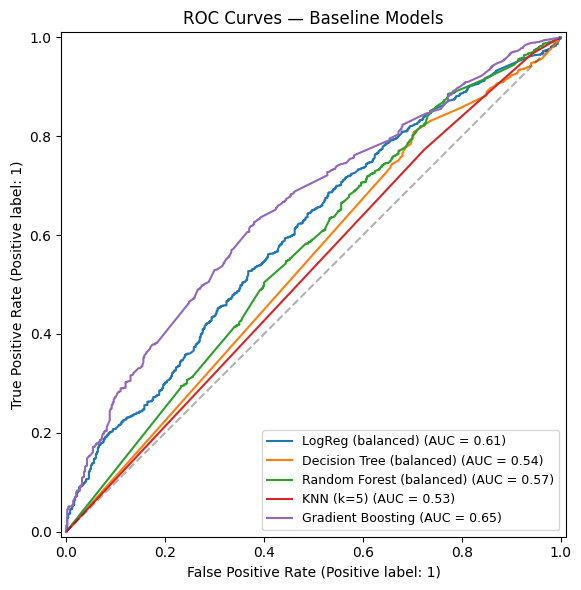

In [ ]:
# ROC CURVES

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC Curves — Baseline Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import RandomizedSearchCV

pipe_gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
}

grid_gb = RandomizedSearchCV(
    pipe_gb, param_grid_gb,
    n_iter=8,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Tuning Gradient Boosting...")
grid_gb.fit(X_train, y_train)

Tuning Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,n_iter,8
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan
